Connect to GitHub

Fatemeh Doshvargar, Hallee Shearer

In [1]:
from getpass import getpass
token = getpass("Enter your GitHub Personal Access Token:")

!pip install git+https://{token}@github.com/neuroprismlab/_MUA_Pipeline.git

Enter your GitHub Personal Access Token:··········
  Cloning https://****@github.com/neuroprismlab/_MUA_Pipeline.git to /tmp/pip-req-build-ba96jg70
  Running command git clone --filter=blob:none --quiet 'https://****@github.com/neuroprismlab/_MUA_Pipeline.git' /tmp/pip-req-build-ba96jg70
  Resolved https://****@github.com/neuroprismlab/_MUA_Pipeline.git to commit 9169856bf76197f12dc2726cb7b8742d939a9410
  Preparing metadata (setup.py) ... done
  Created wheel for mua-pipeline: filename=mua_pipeline-0.1.0-py3-none-any.whl size=22608 sha256=8e5d709a7b6123115e4f42af0433e3d3a9a5a7bbf9f01cb8685ec333665175ce
  Stored in directory: /tmp/pip-ephem-wheel-cache-gaz120kn/wheels/a2/1a/a7/d2145fb21303e5aaa541a77110e5659982f4bbac986fb8555a
Successfully built mua-pipeline


Verify the installation

In [2]:
from mua_pipeline import FeatureVectorizer, MUA, preprocess, plot_results
print("MUA Pipeline installed successfully!")

MUA Pipeline installed successfully!


Other imports

In [3]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, cross_val_predict
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

Create toy data

In [4]:
n_subjects = 1000
n_regions = 200

np.random.seed(42)
connectivity_matrices = np.random.randn(n_subjects, n_regions, n_regions)

for i in range(n_subjects):
    connectivity_matrices[i] = (connectivity_matrices[i] + connectivity_matrices[i].T) / 2
    np.fill_diagonal(connectivity_matrices[i], 1.0)

behavioral_measures = np.random.randn(n_subjects) * 10 + 100

print(f"Data created: {connectivity_matrices.shape} connectivity, {behavioral_measures.shape} behavioral")


Data created: (1000, 200, 200) connectivity, (1000,) behavioral


Preprocessing

In [5]:
clean_conn, clean_behav, removed = preprocess(
    connectivity_matrices,
    behavioral_measures,
    missing_strategy='any',
    verbose=True
)

No subjects with missing data found.


Settings

In [6]:
cv = 10

CPM Pipeline

Original CPM
CPM R2 (10-fold CV): -0.082 +/- 0.077
Correlation: r=0.079, p=1.30e-02
R2: -0.066
MAE: 8.549
RMSE: 10.646


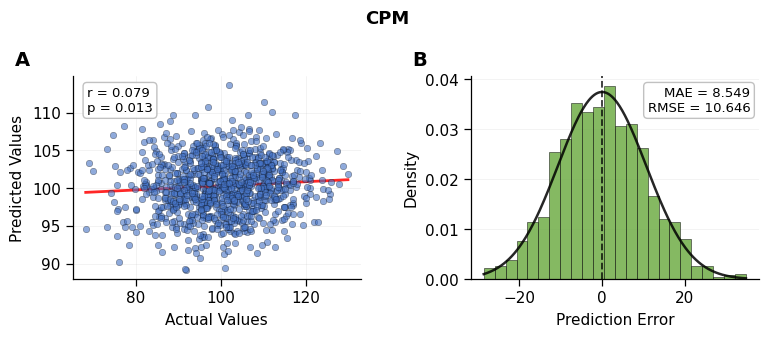

In [7]:
print("Original CPM")

cpm_pipeline = Pipeline([
    ('vectorize', FeatureVectorizer()),
    ('mua', MUA(
        filter_by_sign=True,
        direction='difference',
        selection_method='pvalue',
        selection_threshold=0.05,
        weighting_method='binary',
        feature_aggregation='mean',
    )),
    ('regressor', LinearRegression())
])

cpm_scores = cross_val_score(cpm_pipeline, clean_conn, clean_behav, cv=cv)
cpm_predictions = cross_val_predict(cpm_pipeline, clean_conn, clean_behav, cv=cv)

print(f"CPM R2 ({cv}-fold CV): {cpm_scores.mean():.3f} +/- {cpm_scores.std():.3f}")

cpm_r, cpm_p = pearsonr(clean_behav, cpm_predictions)
print(f"Correlation: r={cpm_r:.3f}, p={cpm_p:.2e}")
print(f"R2: {r2_score(clean_behav, cpm_predictions):.3f}")
print(f"MAE: {mean_absolute_error(clean_behav, cpm_predictions):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(clean_behav, cpm_predictions)):.3f}")

plot_results(cpm_predictions, clean_behav, title="CPM")

PNRS Pipeline

PNRS
PNRS scores shape: (1000, 1)
Correlation: r=0.454, p=3.99e-52


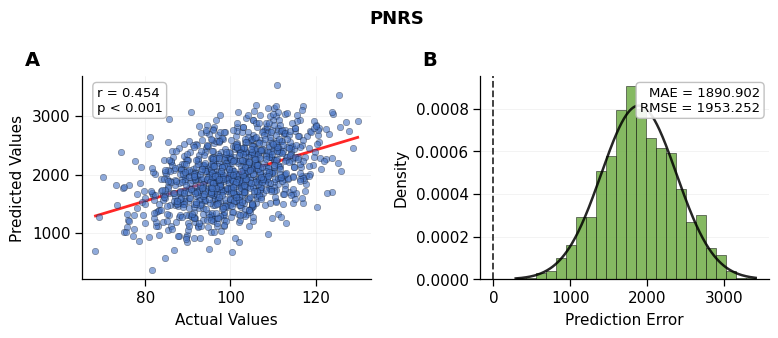

In [8]:
print("PNRS")

pnrs_pipeline = Pipeline([
    ('vectorize', FeatureVectorizer()),
    ('mua', MUA(
        filter_by_sign=False,
        selection_method='all',
        weighting_method='regression',
        feature_aggregation='sum',
    ))
])

pnrs_scores = pnrs_pipeline.fit_transform(clean_conn, clean_behav)
pnrs_predictions = pnrs_scores.flatten()

pnrs_r, pnrs_p = pearsonr(clean_behav, pnrs_predictions)
print(f"PNRS scores shape: {pnrs_scores.shape}")
print(f"Correlation: r={pnrs_r:.3f}, p={pnrs_p:.2e}")

plot_results(pnrs_predictions, clean_behav, title="PNRS")

PCS Computation Using external CSS

In [9]:
n_nodes = clean_conn.shape[1]
triu_idx = np.triu_indices(n_nodes, k=1)
n_edges = len(triu_idx[0])

np.random.seed(99)
external_css = np.random.randn(n_edges)   # one weight per edge

pcs_pipeline = Pipeline([
    ('vectorize', FeatureVectorizer()),
    ('mua', MUA(
        filter_by_sign=False,
        selection_method='all',
        weighting_method='external',
        external_weights=external_css,
        feature_aggregation='mean',
    ))
])

pcs_scores = pcs_pipeline.fit_transform(clean_conn, clean_behav).flatten()

CSS (Connectivity Summary Statistic)

CSS computes a per-edge effect size (here, **Cohen's *d***) from a **group-contrast** design (e.g., patients vs. controls).

In [10]:
# Create a toy discovery dataset with binary group labels
n_discovery = 200
np.random.seed(7)

X_discovery = np.random.randn(n_discovery, n_edges)
group_labels = np.array([0] * (n_discovery // 2) + [1] * (n_discovery // 2))

# Inject a small mean shift in the first 50 edges so there is a real signal
X_discovery[group_labels == 1, :50] += 0.3

css_pipeline = Pipeline([
    ('vectorize', FeatureVectorizer()),
    ('mua', MUA(
        filter_by_sign=False,
        selection_method='all',
        weighting_method='correlation',
        feature_aggregation='sum',
    ))
])

css_pipeline.fit(X_discovery, group_labels)

# Extract correlations and convert to Cohen's d
r = css_pipeline.named_steps['mua'].correlations_

n1 = np.sum(group_labels == 0)   # controls
n2 = np.sum(group_labels == 1)   # patients

h = (n1 + n2 - 2) / n1 + (n1 + n2 - 2) / n2
css_cohen_d = (r / np.sqrt(1 - r ** 2)) * np.sqrt(h)

print(f"Number of edges: {len(css_cohen_d)}")
print(f"Cohen's d — mean: {css_cohen_d.mean():.4f}, std: {css_cohen_d.std():.4f}")
print(f"Edges with |d| > 0.2: {np.sum(np.abs(css_cohen_d) > 0.2)}")

Number of edges: 19900
Cohen's d — mean: 0.0004, std: 0.1421
Edges with |d| > 0.2: 3084


Calculate CSS for **scale-variale**

In [13]:
print("CSS for scale variable (continuous behavioral target)")
n_clean = clean_conn.shape[0]
np.random.seed(21)
y_continuous = np.random.randn(n_clean) * 15 + 50   # continuous scores

# Ensure no zeros
while np.any(y_continuous == 0):
    zero_mask = y_continuous == 0
    y_continuous[zero_mask] = np.random.randn(np.sum(zero_mask)) * 15 + 50

print(f"Target range: [{y_continuous.min():.2f}, {y_continuous.max():.2f}]")
print(f"Any zeros: {np.any(y_continuous == 0)}")

css_cont_pipeline = Pipeline([
    ('vectorize', FeatureVectorizer()),
    ('mua', MUA(
        filter_by_sign=False,
        selection_method='all',
        weighting_method='regression',
        feature_aggregation='sum',
    ))
])

CSS_variables = css_cont_pipeline.fit_transform(clean_conn, y_continuous)
CSS_variables = CSS_variables.flatten()

print(f"Number of edges: {len(CSS_variables)}")
print(f"CSS — mean: {CSS_variables.mean():.4f}, std: {CSS_variables.std():.4f}")
print(f"Edges with |d| > 0.2: {np.sum(np.abs(CSS_variables) > 0.2)}")

CSS for scale variable (continuous behavioral target)
Target range: [-7.79, 96.42]
Any zeros: False
Number of edges: 1000
CSS — mean: 977.3794, std: 364.5591
Edges with |d| > 0.2: 1000
